# 12 · Historical Shadow Validation / Rolling Backtest

## tl;dr

本 Notebook 将 11 已锁定的 Final Hybrid Strategy 按小时回放。**1,423 个 origins、每策略 11,384 个配对预测**上，Hybrid / No-weather Direct / Weekly Naive 的 MAE 分别为 **1,104.69 / 1,140.38 / 1,241.80 rides/hour**；Hybrid 相对 No-weather 总体改善 **3.13%**。但两个天气路由的 1h/3h 都输给 No-weather Direct，12 月 Hybrid 相对它恶化 **27.17%**，最近成熟七日窗口恶化 **38.29%**，研究 warning 有 **3 段、12 天**。因此继续冻结规则的 shadow monitoring，暂不把预测天气作为生产依赖。

**这是 historical shadow simulation，不是新的 2025 blind test**：数据只有 2024 年，shadow 区间与 11 的 Final Test 时间重合，且历史天气文件没有真实天气预报的发布时间。小时起报扩展检验了不同的起报时刻，但不能独立证明未来优势。

## Context & Methods · 冻结规则与时间边界

- Training：2024-01-01 00:00–2024-08-31 23:00，仅此区间用于拟合需求和天气模型。天气训练的 OOF 折仍沿用 11 的 2024-04-01 / 2024-07-01 前向切分。
- Validation：2024-09-01 00:00–2024-10-19 17:00。11 已在这里选择“仅预测降水”和逐 horizon 路由；本 Notebook **只读取锁定结果，不重复任何选择**。
- Historical shadow：2024-10-19 18:00–2024-12-31 23:00。与 11 Final Test 同一时间范围，扩展为每小时起报以模拟更密集的运行；所有 168 小时目标都须在窗口且为有效小时。11 原定每日 00/07/12/18 起报点另作精确复现检查。
- 设 first-future hour 为 `t`，`origin_time=t−1h`，`target_time=t+(h−1)h`。固定三策略：Final Hybrid、No-weather Direct、Weekly Seasonal Naive；三者逐点使用同一 origin/target/horizon。
- Hybrid 固定：1h Forecasted Direct + forecasted precipitation；3h Forecasted Recursive + forecasted precipitation；6/12/24/48/72/168h Weekly Seasonal Naive。HGB 结构、参数、训练样本及特征继承 11。
- 每个 origin 的真实需求和天气历史可用至该 origin；目标日历已知。历史数据中的天气是**实际观测天气**，只在 origin 及以前作为预测天气模型输入。没有外部天气预报档案，也未模拟观测发布延迟。
- 先生成不含 `actual` 的预测日志，再接入目标真实值。完整 8-horizon bundle 的监控结果只在最晚的 168h 标签到达后显示。rolling 指标为最近 7 个日历日、至少 96 个已成熟 origin 的等权 MAE。研究 warning 规则预先固定：每日末的 rolling Hybrid MAE 连续 3 天高于 No-weather Direct **超过 2%**。

**口径限制**：小时起报扩展改变了 11 的评估抽样，但没有改变模型或路由；2024 的这段时间已被项目观察，不能用于声称独立外推验证。

## Data · 原始小时轴、特征和 shadow origins

输入文件：`data/processed/bikeflow_2024.csv`。沿用 11 对春秋 DST 两个特殊目标小时的排除；缺失的春季天气小时只用先前观测前向填充。

In [1]:
from pathlib import Path
from types import MappingProxyType
import hashlib
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from sklearn.ensemble import HistGradientBoostingRegressor

HORIZONS = (1, 3, 6, 12, 24, 48, 72, 168)
WEATHER_COLUMNS = (
    "temperature_2m", "relative_humidity_2m", "precipitation", "wind_speed_10m"
)
DEMAND_COLUMNS = ("lag_1", "lag_24", "lag_168", "rolling_mean_3", "rolling_mean_6")
WEATHER_LAGS = (1, 3, 6, 24, 48, 168)
WEATHER_ROLLS = (3, 6, 24)
DEMAND_PARAMETERS = dict(
    max_iter=240, learning_rate=0.07, max_leaf_nodes=31,
    min_samples_leaf=25, l2_regularization=0.1,
    early_stopping=False, random_state=42,
)
WEATHER_PARAMETERS = dict(
    max_iter=100, learning_rate=0.07, max_leaf_nodes=15,
    min_samples_leaf=30, l2_regularization=0.1,
    early_stopping=False, random_state=42,
)
TRAIN_END = pd.Timestamp("2024-08-31 23:00")
VALIDATION_START = TRAIN_END + pd.Timedelta(hours=1)
TEST_START = pd.Timestamp("2024-10-19 18:00")
VALIDATION_END = TEST_START - pd.Timedelta(hours=1)
TEST_END = pd.Timestamp("2024-12-31 23:00")
VARIANTS = {"No-weather": (), "Precipitation": ("precipitation",)}
PREDICTED_COLUMNS = tuple(f"{name}_pred" for name in WEATHER_COLUMNS)
plt.rcParams.update({
    "figure.figsize": (11, 5), "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "savefig.dpi": 130,
})


# 11 的 Validation 锁定产物；校验哈希，不在 shadow 中重新选择。
WEATHER_HORIZONS = (1, 3)
STRATEGIES = ("Final Hybrid", "No-weather Direct", "Weekly Seasonal Naive")
locked_route = MappingProxyType({
    1: "Forecasted Direct", 3: "Forecasted Recursive",
    6: "Weekly Seasonal Naive", 12: "Weekly Seasonal Naive",
    24: "Weekly Seasonal Naive", 48: "Weekly Seasonal Naive",
    72: "Weekly Seasonal Naive", 168: "Weekly Seasonal Naive",
})
lock_payload = {
    "train_end": str(TRAIN_END), "validation_end": str(VALIDATION_END),
    "test_start": str(TEST_START), "weather_variant": "Precipitation",
    "weather_inputs": ["precipitation"],
    "route": {str(h): locked_route[h] for h in HORIZONS},
    "single_model": "Weekly Seasonal Naive",
    "demand_parameters": DEMAND_PARAMETERS, "weather_parameters": WEATHER_PARAMETERS,
}
lock_fingerprint = hashlib.sha256(
    json.dumps(lock_payload, sort_keys=True, default=str).encode("utf-8")
).hexdigest()[:16]
assert lock_fingerprint == "6f2460944230dfd5"

# 以下是事先指定的研究监控规则，不由 shadow 分数调节。
ROLLING_DAYS = 7
MIN_MATURED_ORIGINS = 96
WARNING_RELATIVE_MARGIN = 0.02
WARNING_CONSECUTIVE_DAYS = 3
palette = {
    "Final Hybrid": "#1E6B53",
    "No-weather Direct": "#4E7894",
    "Weekly Seasonal Naive": "#787878",
}
print("11 frozen lock fingerprint:", lock_fingerprint)


11 frozen lock fingerprint: 6f2460944230dfd5


In [2]:
project_root = Path.cwd()
if not (project_root / "data" / "processed" / "bikeflow_2024.csv").exists():
    project_root = project_root.parent
data_path = project_root / "data" / "processed" / "bikeflow_2024.csv"
data = pd.read_csv(data_path, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
assert len(data) == 8784 and data["timestamp"].is_unique
assert data["timestamp"].diff().iloc[1:].eq(pd.Timedelta(hours=1)).all()
assert data["ride_count"].notna().all()
assert set(WEATHER_COLUMNS).issubset(data.columns)
for lag in (1, 24, 168):
    data[f"lag_{lag}"] = data["ride_count"].shift(lag)
for window in (3, 6):
    data[f"rolling_mean_{window}"] = data["ride_count"].shift(1).rolling(window).mean()
spring_gap = pd.Timestamp("2024-03-10 02:00")
fall_repeat = pd.Timestamp("2024-11-03 01:00")
model_data = data.loc[~data["timestamp"].isin([spring_gap, fall_repeat])].copy().reset_index(drop=True)
assert len(model_data) == 8782
observed_demand = data.set_index("timestamp")["ride_count"]
observed_weather_raw = data.set_index("timestamp")[list(WEATHER_COLUMNS)]
observed_weather = observed_weather_raw.ffill()
assert observed_weather.notna().all(axis=None)
assert observed_weather_raw.loc[spring_gap].isna().all()
print("数据来源：", data_path)
print("原始连续小时：", len(data), "；可作为目标的小时：", len(model_data))


数据来源： C:\Users\txy18\Desktop\BikeFlow\data\processed\bikeflow_2024.csv
原始连续小时： 8784 ；可作为目标的小时： 8782


In [3]:
timestamps = pd.DatetimeIndex(model_data["timestamp"])
calendar_parts = pd.DataFrame({
    "target_hour": pd.Categorical(timestamps.hour, categories=range(24)),
    "target_day_of_week": pd.Categorical(timestamps.dayofweek, categories=range(7)),
    "target_month": pd.Categorical(timestamps.month, categories=range(1, 13)),
})
calendar_full = pd.get_dummies(calendar_parts, drop_first=True, dtype=int)
train_calendar_mask = timestamps <= TRAIN_END
calendar_columns = calendar_full.columns[calendar_full.loc[train_calendar_mask].any(axis=0)].tolist()
calendar_target = calendar_full[calendar_columns].copy()
calendar_target.index = timestamps
origin_demand = model_data[list(DEMAND_COLUMNS)].copy()
origin_demand.index = timestamps
weather_target = model_data[list(WEATHER_COLUMNS)].copy()
weather_target.index = timestamps

valid_lags = model_data[list(DEMAND_COLUMNS)].notna().all(axis=1)
candidate_train = pd.DatetimeIndex(model_data.loc[valid_lags & (model_data["timestamp"] <= TRAIN_END), "timestamp"])
training_specs = {}
for horizon in HORIZONS:
    targets = candidate_train + pd.Timedelta(hours=horizon - 1)
    keep = targets.isin(timestamps) & (targets <= TRAIN_END)
    training_specs[horizon] = (candidate_train[keep], targets[keep])
    assert len(training_specs[horizon][0]) > 4000


In [4]:
SHADOW_START, SHADOW_END = TEST_START, TEST_END
eligible_targets = set(model_data.loc[
    model_data["timestamp"].between(SHADOW_START, SHADOW_END), "timestamp"
])
valid_start_times = set(model_data.loc[valid_lags, "timestamp"])

def common_hourly_starts(window_start, window_end):
    # 每个候选起点的全部 168 个目标都须属于可评估的日历小时。
    candidates = pd.date_range(
        window_start, window_end - pd.Timedelta(hours=167), freq="h"
    )
    return pd.DatetimeIndex([
        start for start in candidates
        if start in valid_start_times and all(
            start + pd.Timedelta(hours=step) in eligible_targets
            for step in range(168)
        )
    ])

shadow_starts = common_hourly_starts(SHADOW_START, SHADOW_END)
original_schedule_starts = shadow_starts[
    shadow_starts.hour.isin((0, 7, 12, 18))
]
assert len(shadow_starts) == 1423
assert len(original_schedule_starts) == 238
assert (shadow_starts - pd.Timedelta(hours=1) >= TRAIN_END).all()
assert (shadow_starts + pd.Timedelta(hours=167) <= SHADOW_END).all()
display(pd.DataFrame([{
    "Shadow target window": f"{SHADOW_START} to {SHADOW_END}",
    "First / last first-future hour": f"{shadow_starts.min()} / {shadow_starts.max()}",
    "Hourly origins": len(shadow_starts),
    "11 schedule origins": len(original_schedule_starts),
    "Pairs per strategy": len(shadow_starts) * len(HORIZONS),
}]))


,Shadow target window,First / last first-future hour,Hourly origins,11 schedule origins,Pairs per strategy
0,2024-10-19 18:00:00 to 2024-12-31 23:00:00,2024-10-19 18:00:00 / 2024-12-25 00:00:00,1423,238,11384


## Weather & demand models · 精确复现 11 的必要模型

天气模型使用目标日历和截至 origin 的四变量天气 lag/rolling。需求模型只拟合本次固定三策略需要的分支：No-weather Direct 八个 horizon、Precipitation 的 1h 模型。3h Recursive 反复调用该 1h 需求模型；第 2 小时天气由 1h 天气模型递归生成，第 3 小时使用 3h 直接天气锚点。虽然只用预测降水作为需求输入，递归天气特征仍需要四个变量的 1h 天气预测，故保留 11 的四变量天气路径。

模型结构、参数、训练配对、天气 OOF 和特征顺序均沿用 11。没有模型、天气变量或超参数搜索。

In [5]:
weather_history = pd.DataFrame(index=observed_weather.index)
for variable in WEATHER_COLUMNS:
    prior = observed_weather[variable].shift(1)
    for lag in WEATHER_LAGS:
        weather_history[f"{variable}_lag_{lag}"] = observed_weather[variable].shift(lag)
    for window in WEATHER_ROLLS:
        weather_history[f"{variable}_roll_mean_{window}"] = prior.rolling(window).mean()
        weather_history[f"{variable}_roll_std_{window}"] = prior.rolling(window).std(ddof=0)
weather_calendar = calendar_target.copy()
weather_calendar["weather_target_weekend"] = (timestamps.dayofweek >= 5).astype(int)
weather_calendar["weather_target_hour_sin"] = np.sin(2 * np.pi * timestamps.hour / 24)
weather_calendar["weather_target_hour_cos"] = np.cos(2 * np.pi * timestamps.hour / 24)
weather_calendar["weather_target_doy_sin"] = np.sin(2 * np.pi * timestamps.dayofyear / 366)
weather_calendar["weather_target_doy_cos"] = np.cos(2 * np.pi * timestamps.dayofyear / 366)
weather_input_columns = list(weather_calendar.columns) + list(weather_history.columns)

def make_weather_matrix(starts, targets):
    starts, targets = pd.DatetimeIndex(starts), pd.DatetimeIndex(targets)
    assert len(starts) == len(targets)
    assert (targets > starts - pd.Timedelta(hours=1)).all()
    parts = [
        weather_calendar.loc[targets].reset_index(drop=True),
        weather_history.loc[starts].reset_index(drop=True),
    ]
    matrix = pd.concat(parts, axis=1)[weather_input_columns]
    assert matrix.notna().all(axis=None)
    assert set(matrix.columns).isdisjoint(WEATHER_COLUMNS)
    return matrix

def weather_weekly_warmup(starts, targets):
    starts, targets = pd.DatetimeIndex(starts), pd.DatetimeIndex(targets)
    source = targets - pd.Timedelta(hours=168)
    assert (source <= starts - pd.Timedelta(hours=1)).all()
    result = observed_weather.reindex(source).reset_index(drop=True)
    assert result.notna().all(axis=None)
    return result

for horizon in HORIZONS:
    starts, targets = training_specs[horizon]
    matrix = make_weather_matrix(starts, targets)
    assert (starts <= TRAIN_END).all() and (targets <= TRAIN_END).all()
    for lag in WEATHER_LAGS:
        source = starts - pd.Timedelta(hours=lag)
        assert (source <= starts - pd.Timedelta(hours=1)).all()
        for variable in WEATHER_COLUMNS:
            np.testing.assert_allclose(
                matrix[f"{variable}_lag_{lag}"].to_numpy(),
                observed_weather[variable].reindex(source).to_numpy(),
            )
print("Weather feature timing audit: PASS；", len(weather_input_columns), "weather model inputs")


Weather feature timing audit: PASS； 89 weather model inputs


In [6]:
OOF_CUTOFFS = (pd.Timestamp("2024-04-01 00:00"), pd.Timestamp("2024-07-01 00:00"))
oof_weather = {}
oof_audit_rows = []
for horizon in WEATHER_HORIZONS:
    starts, targets = training_specs[horizon]
    forecast = weather_weekly_warmup(starts, targets).to_numpy(copy=True)
    source_type = np.full(len(starts), "prior-week warm-up", dtype=object)
    for fold_start, fold_end in zip(OOF_CUTOFFS, (*OOF_CUTOFFS[1:], VALIDATION_START)):
        fit = targets < fold_start
        predict = (starts >= fold_start) & (starts < fold_end)
        if not predict.any():
            continue
        assert fit.any() and (targets[fit] < fold_start).all()
        assert (starts[predict] >= fold_start).all()
        fit_x = make_weather_matrix(starts[fit], targets[fit])
        predict_x = make_weather_matrix(starts[predict], targets[predict])
        for index, variable in enumerate(WEATHER_COLUMNS):
            fold_model = HistGradientBoostingRegressor(**WEATHER_PARAMETERS)
            fold_model.fit(fit_x, weather_target.loc[targets[fit], variable].to_numpy())
            forecast[predict, index] = fold_model.predict(predict_x)
        source_type[predict] = f"HGB labels before {fold_start.date()}"
        oof_audit_rows.append({
            "Horizon": horizon, "Fold start": fold_start,
            "Last fit target": targets[fit].max(),
            "First forecast origin": (starts[predict] - pd.Timedelta(hours=1)).min(),
            "Forecast rows": int(predict.sum()),
        })
    assert np.isfinite(forecast).all()
    assert (starts[source_type == "prior-week warm-up"] < OOF_CUTOFFS[0]).all()
    oof_weather[horizon] = pd.DataFrame(forecast, columns=PREDICTED_COLUMNS)
    print(f"Forward OOF weather: h={horizon:>3}h, {len(starts):,} training pairs")
oof_audit = pd.DataFrame(oof_audit_rows)
assert (oof_audit["Last fit target"] < oof_audit["Fold start"]).all()
assert (oof_audit["Last fit target"] <= oof_audit["First forecast origin"]).all()
display(oof_audit)


Forward OOF weather: h=  1h, 5,687 training pairs


Forward OOF weather: h=  3h, 5,684 training pairs


,Horizon,Fold start,Last fit target,First forecast origin,Forecast rows
0,1,2024-04-01,2024-03-31 23:00:00,2024-03-31 23:00:00,2184
1,1,2024-07-01,2024-06-30 23:00:00,2024-06-30 23:00:00,1488
2,3,2024-04-01,2024-03-31 23:00:00,2024-03-31 23:00:00,2184
3,3,2024-07-01,2024-06-30 23:00:00,2024-06-30 23:00:00,1486


In [7]:
weather_models = {}
for horizon in WEATHER_HORIZONS:
    starts, targets = training_specs[horizon]
    matrix = make_weather_matrix(starts, targets)
    weather_models[horizon] = {}
    for variable in WEATHER_COLUMNS:
        fitted = HistGradientBoostingRegressor(**WEATHER_PARAMETERS)
        fitted.fit(matrix, weather_target.loc[targets, variable].to_numpy())
        weather_models[horizon][variable] = fitted
    print(f"Fixed Training-only weather models: h={horizon:>3}h")

def predict_weather_direct(starts, targets, horizon):
    starts, targets = pd.DatetimeIndex(starts), pd.DatetimeIndex(targets)
    assert (targets == starts + pd.Timedelta(hours=horizon - 1)).all()
    matrix = make_weather_matrix(starts, targets)
    result = np.column_stack([
        weather_models[horizon][variable].predict(matrix) for variable in WEATHER_COLUMNS
    ])
    assert np.isfinite(result).all()
    return result

def predict_weather_path(starts):
    starts = pd.DatetimeIndex(starts)
    origins = starts - pd.Timedelta(hours=1)
    prediction = np.full((len(starts), 3, len(WEATHER_COLUMNS)), np.nan)
    anchors = {
        lead: predict_weather_direct(
            starts, starts + pd.Timedelta(hours=lead - 1), lead
        ) for lead in WEATHER_HORIZONS
    }
    def previous(variable, variable_index, targets, step, lag):
        if step <= lag:
            source = targets - pd.Timedelta(hours=lag)
            assert (source <= origins).all()
            return observed_weather[variable].reindex(source).to_numpy()
        return prediction[:, step - lag - 1, variable_index]
    for step in range(1, 4):
        if step in anchors:
            prediction[:, step - 1, :] = anchors[step]
            continue
        targets = starts + pd.Timedelta(hours=step - 1)
        row = weather_calendar.loc[targets].reset_index(drop=True).copy()
        for variable_index, variable in enumerate(WEATHER_COLUMNS):
            for lag in WEATHER_LAGS:
                row[f"{variable}_lag_{lag}"] = previous(variable, variable_index, targets, step, lag)
            for window in WEATHER_ROLLS:
                prior = np.column_stack([
                    previous(variable, variable_index, targets, step, lag)
                    for lag in range(1, window + 1)
                ])
                row[f"{variable}_roll_mean_{window}"] = prior.mean(axis=1)
                row[f"{variable}_roll_std_{window}"] = prior.std(axis=1, ddof=0)
        matrix = row[weather_input_columns]
        assert matrix.notna().all(axis=None)
        prediction[:, step - 1, :] = np.column_stack([
            weather_models[1][variable].predict(matrix) for variable in WEATHER_COLUMNS
        ])
    assert np.isfinite(prediction).all()
    for lead, values in anchors.items():
        np.testing.assert_allclose(prediction[:, lead - 1, :], values)
    return prediction


Fixed Training-only weather models: h=  1h


Fixed Training-only weather models: h=  3h


In [8]:
def variant_columns(variant):
    return (
        calendar_columns
        + [f"{variable}_pred" for variable in VARIANTS[variant]]
        + list(DEMAND_COLUMNS)
    )

def make_demand_matrix(variant, starts, targets, predicted_weather=None):
    starts, targets = pd.DatetimeIndex(starts), pd.DatetimeIndex(targets)
    assert len(starts) == len(targets)
    assert (targets > starts - pd.Timedelta(hours=1)).all()
    parts = [calendar_target.loc[targets].reset_index(drop=True)]
    if VARIANTS[variant]:
        assert predicted_weather is not None
        assert predicted_weather.shape == (len(starts), len(WEATHER_COLUMNS))
        weather_part = pd.DataFrame(predicted_weather, columns=PREDICTED_COLUMNS)
        parts.append(weather_part[[f"{variable}_pred" for variable in VARIANTS[variant]]])
    parts.append(origin_demand.loc[starts, list(DEMAND_COLUMNS)].reset_index(drop=True))
    matrix = pd.concat(parts, axis=1)[variant_columns(variant)]
    assert matrix.notna().all(axis=None)
    assert set(matrix.columns).isdisjoint(WEATHER_COLUMNS)
    return matrix

demand_models = {}
for variant in VARIANTS:
    demand_models[variant] = {}
    for horizon in (HORIZONS if variant == "No-weather" else WEATHER_HORIZONS):
        starts, targets = training_specs[horizon]
        training_weather = oof_weather[horizon].to_numpy() if VARIANTS[variant] else None
        matrix = make_demand_matrix(variant, starts, targets, training_weather)
        labels = observed_demand.reindex(targets).to_numpy()
        model = HistGradientBoostingRegressor(**DEMAND_PARAMETERS)
        model.fit(matrix, labels)
        demand_models[variant][horizon] = model
    print(f"Training-only demand models: {variant}, {len(demand_models[variant])} horizons")


Training-only demand models: No-weather, 8 horizons


Training-only demand models: Precipitation, 2 horizons


In [9]:
def recursive_demand_predict(starts, variant, weather_path=None, history=None):
    starts = pd.DatetimeIndex(starts)
    origins = starts - pd.Timedelta(hours=1)
    history = observed_demand if history is None else history
    prediction = np.full((len(starts), 3), np.nan)
    if VARIANTS[variant]:
        assert weather_path is not None
        assert weather_path.shape == (len(starts), 3, len(WEATHER_COLUMNS))
    for step in range(1, 4):
        targets = starts + pd.Timedelta(hours=step - 1)
        row = calendar_target.loc[targets].reset_index(drop=True).copy()
        if VARIANTS[variant]:
            for variable in VARIANTS[variant]:
                variable_index = WEATHER_COLUMNS.index(variable)
                row[f"{variable}_pred"] = weather_path[:, step - 1, variable_index]
        for lag in (1, 24, 168):
            if step <= lag:
                source = targets - pd.Timedelta(hours=lag)
                assert (source <= origins).all()
                row[f"lag_{lag}"] = history.reindex(source).to_numpy()
            else:
                row[f"lag_{lag}"] = prediction[:, step - lag - 1]
        for window in (3, 6):
            prior = []
            for back in range(1, window + 1):
                if step <= back:
                    source = targets - pd.Timedelta(hours=back)
                    assert (source <= origins).all()
                    prior.append(history.reindex(source).to_numpy())
                else:
                    prior.append(prediction[:, step - back - 1])
            row[f"rolling_mean_{window}"] = np.column_stack(prior).mean(axis=1)
        matrix = row[variant_columns(variant)]
        assert matrix.notna().all(axis=None)
        prediction[:, step - 1] = demand_models[variant][1].predict(matrix)
    assert np.isfinite(prediction).all()
    return prediction


## Shadow replay · 先预测，后评分

以下函数只返回预测和来源时刻；这里**没有读取 target actual demand**。按连续 24 个小时起报点分批执行，批内每行都独立使用自己的 origin 信息边界。天气字段说明的是历史观测驱动的 HGB 预测，绝非实际发布过的天气预报。

In [10]:
def predict_origin_batch(starts):
    starts = pd.DatetimeIndex(starts)
    origins = starts - pd.Timedelta(hours=1)
    weather_path = predict_weather_path(starts)
    precipitation_recursive = recursive_demand_predict(
        starts, "Precipitation", weather_path
    )
    frames = []
    for horizon in HORIZONS:
        targets = starts + pd.Timedelta(hours=horizon - 1)
        weekly_source = targets - pd.Timedelta(hours=168)
        assert (weekly_source <= origins).all()
        no_weather = demand_models["No-weather"][horizon].predict(
            make_demand_matrix("No-weather", starts, targets)
        )
        weekly = observed_demand.reindex(weekly_source).to_numpy()
        if horizon == 1:
            hybrid = demand_models["Precipitation"][1].predict(
                make_demand_matrix(
                    "Precipitation", starts, targets, weather_path[:, 0, :]
                )
            )
        elif horizon == 3:
            hybrid = precipitation_recursive[:, 2]
        else:
            hybrid = weekly
        values = {
            "Final Hybrid": hybrid,
            "No-weather Direct": no_weather,
            "Weekly Seasonal Naive": weekly,
        }
        for strategy, prediction in values.items():
            uses_weather = strategy == "Final Hybrid" and horizon in (1, 3)
            demand_source = (
                weekly_source if strategy == "Weekly Seasonal Naive"
                or (strategy == "Final Hybrid" and horizon >= 6)
                else origins
            )
            frames.append(pd.DataFrame({
                "origin_time": origins,
                "first_future_hour": starts,
                "target_time": targets,
                "horizon": horizon,
                "strategy": strategy,
                "prediction": prediction,
                "weather_source": (
                    "Training-only HGB precipitation forecast; observed history <= origin"
                    if uses_weather else "none"
                ),
                "latest_actual_demand_source": demand_source,
                "latest_actual_weather_source": origins if uses_weather else pd.NaT,
                "model_fit_label_cutoff": (
                    TRAIN_END if strategy == "No-weather Direct" or uses_weather
                    else pd.NaT
                ),
            }))
    return pd.concat(frames, ignore_index=True)

forecast_batches = []
for batch_start in range(0, len(shadow_starts), 24):
    forecast_batches.append(predict_origin_batch(shadow_starts[batch_start:batch_start + 24]))
unscored_predictions = pd.concat(forecast_batches, ignore_index=True)
assert "actual" not in unscored_predictions.columns
assert len(unscored_predictions) == len(shadow_starts) * len(HORIZONS) * len(STRATEGIES)
assert not unscored_predictions.duplicated(
    ["origin_time", "target_time", "horizon", "strategy"]
).any()
assert np.isfinite(unscored_predictions["prediction"]).all()
assert unscored_predictions["latest_actual_demand_source"].le(
    unscored_predictions["origin_time"]
).all()
print("Unscored forecast rows:", len(unscored_predictions))
display(unscored_predictions[[
    "origin_time", "target_time", "horizon", "strategy", "prediction", "weather_source"
]].head(9))


Unscored forecast rows: 34152


,origin_time,target_time,horizon,strategy,prediction,weather_source
0,2024-10-19 17:00:00,2024-10-19 18:00:00,1,Final Hybrid,11739.092701,Training-only HGB precipitation forecast; obse...
1,2024-10-19 18:00:00,2024-10-19 19:00:00,1,Final Hybrid,9919.357879,Training-only HGB precipitation forecast; obse...
2,2024-10-19 19:00:00,2024-10-19 20:00:00,1,Final Hybrid,6464.251121,Training-only HGB precipitation forecast; obse...
3,2024-10-19 20:00:00,2024-10-19 21:00:00,1,Final Hybrid,5487.091954,Training-only HGB precipitation forecast; obse...
4,2024-10-19 21:00:00,2024-10-19 22:00:00,1,Final Hybrid,5172.445264,Training-only HGB precipitation forecast; obse...
5,2024-10-19 22:00:00,2024-10-19 23:00:00,1,Final Hybrid,4451.619436,Training-only HGB precipitation forecast; obse...
6,2024-10-19 23:00:00,2024-10-20 00:00:00,1,Final Hybrid,3827.072987,Training-only HGB precipitation forecast; obse...
7,2024-10-20 00:00:00,2024-10-20 01:00:00,1,Final Hybrid,3383.626427,Training-only HGB precipitation forecast; obse...
8,2024-10-20 01:00:00,2024-10-20 02:00:00,1,Final Hybrid,1987.172827,Training-only HGB precipitation forecast; obse...


## Checks · Leakage audit before outcomes are attached

逐行审计历史来源不晚于 origin、训练标签不晚于 Training 截止、未来真实天气不在需求输入列中。再对三个起报点分别扰动 origin 之后的所有真实需求与天气，并**重建** demand/weather lag 特征；预测必须逐值不变。此反事实检查只验证这些样本和当前代码路径，不能替代未来生产数据可用性检查。

In [11]:
assert lock_fingerprint == hashlib.sha256(
    json.dumps(lock_payload, sort_keys=True, default=str).encode("utf-8")
).hexdigest()[:16] == "6f2460944230dfd5"
assert set(locked_route) == set(HORIZONS)
assert all(training_specs[h][1].max() <= TRAIN_END for h in HORIZONS)
assert (oof_audit["Last fit target"] < oof_audit["Fold start"]).all()
assert (unscored_predictions["target_time"] > unscored_predictions["origin_time"]).all()
assert unscored_predictions["latest_actual_weather_source"].dropna().le(
    unscored_predictions.loc[
        unscored_predictions["latest_actual_weather_source"].notna(), "origin_time"
    ]
).all()
assert unscored_predictions["model_fit_label_cutoff"].dropna().le(TRAIN_END).all()
assert set(make_demand_matrix(
    "Precipitation", [shadow_starts[0]], [shadow_starts[0]],
    predict_weather_path([shadow_starts[0]])[:, 0, :]
).columns).isdisjoint(WEATHER_COLUMNS)

def rebuild_demand_features(history):
    frame = pd.DataFrame({
        "timestamp": data["timestamp"],
        "ride_count": history.reindex(data["timestamp"]).to_numpy(),
    })
    for lag in (1, 24, 168):
        frame[f"lag_{lag}"] = frame["ride_count"].shift(lag)
    for window in (3, 6):
        frame[f"rolling_mean_{window}"] = frame["ride_count"].shift(1).rolling(window).mean()
    return frame.set_index("timestamp").loc[timestamps, list(DEMAND_COLUMNS)]

def rebuild_weather_features(history):
    frame = pd.DataFrame(index=history.index)
    for variable in WEATHER_COLUMNS:
        prior = history[variable].shift(1)
        for lag in WEATHER_LAGS:
            frame[f"{variable}_lag_{lag}"] = history[variable].shift(lag)
        for window in WEATHER_ROLLS:
            frame[f"{variable}_roll_mean_{window}"] = prior.rolling(window).mean()
            frame[f"{variable}_roll_std_{window}"] = prior.rolling(window).std(ddof=0)
    return frame

checked_origins = []
for sample_start in (shadow_starts[0], shadow_starts[len(shadow_starts)//2], shadow_starts[-1]):
    sample_origin = sample_start - pd.Timedelta(hours=1)
    reference = predict_origin_batch([sample_start]).sort_values(
        ["horizon", "strategy"]
    )["prediction"].to_numpy()
    original_demand, original_weather = observed_demand, observed_weather
    original_demand_features, original_weather_features = origin_demand, weather_history
    try:
        observed_demand = original_demand.copy()
        observed_demand.loc[observed_demand.index > sample_origin] += 1_000_000
        observed_weather = original_weather.copy()
        observed_weather.loc[observed_weather.index > sample_origin, :] += 1_000_000
        origin_demand = rebuild_demand_features(observed_demand)
        weather_history = rebuild_weather_features(observed_weather)
        perturbed = predict_origin_batch([sample_start]).sort_values(
            ["horizon", "strategy"]
        )["prediction"].to_numpy()
    finally:
        observed_demand, observed_weather = original_demand, original_weather
        origin_demand, weather_history = original_demand_features, original_weather_features
    np.testing.assert_array_equal(reference, perturbed)
    checked_origins.append(sample_origin)

audit_table = pd.DataFrame([
    {"Audit": "Frozen 11 route / weather / parameters / lock hash", "Status": "PASS"},
    {"Audit": "Training and OOF target-time boundaries", "Status": "PASS"},
    {"Audit": "All actual demand/weather source times <= own origin", "Status": "PASS"},
    {"Audit": "No future actual weather columns in demand matrix", "Status": "PASS"},
    {"Audit": "Post-origin demand/weather perturbation with feature rebuild", "Status": "PASS"},
    {"Audit": "No shadow labels used for model or route selection", "Status": "PASS"},
])
display(audit_table)
print("Counterfactual origins:", checked_origins)
print("实际值尚未合并；训练与预测代码中没有 shadow 结果选择步骤。")


,Audit,Status
0,Frozen 11 route / weather / parameters / lock ...,PASS
1,Training and OOF target-time boundaries,PASS
2,All actual demand/weather source times <= own ...,PASS
3,No future actual weather columns in demand matrix,PASS
4,Post-origin demand/weather perturbation with f...,PASS
5,No shadow labels used for model or route selec...,PASS


Counterfactual origins: [Timestamp('2024-10-19 17:00:00'), Timestamp('2024-11-25 08:00:00'), Timestamp('2024-12-24 23:00:00')]
实际值尚未合并；训练与预测代码中没有 shadow 结果选择步骤。


## Results · 同点位评分与 11 复现检查

从这里才按 `target_time` 接入 `actual`。误差单位为 rides/hour。Worst-decile MAE = 按 AE 降序取 `ceil(10% × N)` 个预测的平均 AE；汇总指标在全部配对行上直接计算。11 的四时刻子集用于确认精简训练复现既有结果，不据此修改模型或路由。

In [12]:
actual_lookup = observed_demand.rename("actual").reset_index().rename(
    columns={"timestamp": "target_time"}
)
prediction_log = unscored_predictions.merge(
    actual_lookup, on="target_time", how="left", validate="many_to_one"
)
prediction_log["absolute_error"] = (
    prediction_log["actual"] - prediction_log["prediction"]
).abs()
prediction_log["squared_error"] = (
    prediction_log["actual"] - prediction_log["prediction"]
) ** 2
prediction_log["feedback_time"] = (
    prediction_log["origin_time"] + pd.Timedelta(hours=168)
)
prediction_log = prediction_log.sort_values(
    ["origin_time", "horizon", "strategy"], kind="stable"
).reset_index(drop=True)
assert prediction_log[["prediction", "actual", "absolute_error", "squared_error"]].notna().all().all()
assert prediction_log.groupby("strategy").size().eq(len(shadow_starts) * len(HORIZONS)).all()
assert prediction_log.groupby(
    ["origin_time", "target_time", "horizon"]
)["strategy"].nunique().eq(3).all()
assert prediction_log.groupby(
    ["origin_time", "target_time", "horizon"]
)["actual"].nunique().eq(1).all()
display(prediction_log[[
    "origin_time", "target_time", "horizon", "strategy", "prediction", "actual",
    "absolute_error", "squared_error", "weather_source"
]].head(9))
print("Prediction log rows:", len(prediction_log))


,origin_time,target_time,horizon,strategy,prediction,actual,absolute_error,squared_error,weather_source
0,2024-10-19 17:00:00,2024-10-19 18:00:00,1,Final Hybrid,11739.092701,11471,268.092701,7.187370e+04,Training-only HGB precipitation forecast; obse...
1,2024-10-19 17:00:00,2024-10-19 18:00:00,1,No-weather Direct,11709.094910,11471,238.094910,5.668919e+04,none
2,2024-10-19 17:00:00,2024-10-19 18:00:00,1,Weekly Seasonal Naive,11670.000000,11471,199.000000,3.960100e+04,none
3,2024-10-19 17:00:00,2024-10-19 20:00:00,3,Final Hybrid,8150.762453,6997,1153.762453,1.331168e+06,Training-only HGB precipitation forecast; obse...
4,2024-10-19 17:00:00,2024-10-19 20:00:00,3,No-weather Direct,7543.300631,6997,546.300631,2.984444e+05,none
5,2024-10-19 17:00:00,2024-10-19 20:00:00,3,Weekly Seasonal Naive,7198.000000,6997,201.000000,4.040100e+04,none
6,2024-10-19 17:00:00,2024-10-19 23:00:00,6,Final Hybrid,4616.000000,4922,306.000000,9.363600e+04,none
7,2024-10-19 17:00:00,2024-10-19 23:00:00,6,No-weather Direct,5054.530413,4922,132.530413,1.756431e+04,none
8,2024-10-19 17:00:00,2024-10-19 23:00:00,6,Weekly Seasonal Naive,4616.000000,4922,306.000000,9.363600e+04,none


Prediction log rows: 34152


In [13]:
def scores_from_log(frame):
    errors = frame["absolute_error"].to_numpy()
    worst_count = max(1, math.ceil(len(errors) * 0.10))
    return {
        "N": len(errors),
        "MAE": errors.mean(),
        "RMSE": np.sqrt(frame["squared_error"].mean()),
        "Median AE": np.median(errors),
        "P90 AE": np.quantile(errors, 0.9),
        "Worst-decile MAE": np.sort(errors)[-worst_count:].mean(),
    }

overall_metrics = pd.DataFrame([
    {"Strategy": strategy, **scores_from_log(prediction_log.loc[
        prediction_log["strategy"].eq(strategy)
    ])} for strategy in STRATEGIES
])
horizon_metrics = pd.DataFrame([
    {"Horizon": horizon, "Strategy": strategy, **scores_from_log(frame)}
    for (horizon, strategy), frame in prediction_log.groupby(
        ["horizon", "strategy"], sort=True
    )
])
display(overall_metrics.round(2))
display(horizon_metrics.pivot(
    index="Horizon", columns="Strategy", values="MAE"
)[list(STRATEGIES)].round(2))

eleven_schedule_log = prediction_log.loc[
    prediction_log["first_future_hour"].isin(original_schedule_starts)
]
eleven_schedule_metrics = pd.DataFrame([
    {"Strategy": strategy, **scores_from_log(eleven_schedule_log.loc[
        eleven_schedule_log["strategy"].eq(strategy)
    ])} for strategy in STRATEGIES
])
expected_11_mae = {
    "Final Hybrid": 1125.53,
    "No-weather Direct": 1131.71,
    "Weekly Seasonal Naive": 1284.35,
}
for _, row in eleven_schedule_metrics.iterrows():
    assert row["N"] == 1904
    assert abs(row["MAE"] - expected_11_mae[row["Strategy"]]) < 0.02
print("11 的每日四时刻子集复现：PASS（MAE 与 11 保存输出差 < 0.02）")
display(eleven_schedule_metrics.round(2))


,Strategy,N,MAE,RMSE,Median AE,P90 AE,Worst-decile MAE
0,Final Hybrid,11384,1104.69,1772.44,595.00,2903.00,4339.94
1,No-weather Direct,11384,1140.38,1761.82,630.06,2981.11,4306.20
2,Weekly Seasonal Naive,11384,1241.80,1925.91,709.00,3110.00,4610.30


Strategy,Final Hybrid,No-weather Direct,Weekly Seasonal Naive
Horizon,,,
1,431.65,419.03,1196.02
3,862.43,844.86,1194.97
6,1194.90,1427.28,1194.90
12,1216.53,1473.66,1216.53
24,1255.61,1035.86,1255.61
48,1290.89,1240.23,1290.89
72,1285.30,1389.26,1285.30
168,1300.17,1292.84,1300.17


11 的每日四时刻子集复现：PASS（MAE 与 11 保存输出差 < 0.02）


,Strategy,N,MAE,RMSE,Median AE,P90 AE,Worst-decile MAE
0,Final Hybrid,1904,1125.53,1821.07,629.29,2703.00,4411.08
1,No-weather Direct,1904,1131.71,1798.36,661.70,2683.47,4478.97
2,Weekly Seasonal Naive,1904,1284.35,1993.48,743.00,3051.00,4753.69


## Stability · month、day type、peak 与 horizon

Peak 与 11 同口径：目标时刻为工作日 07–09 或 16–19；其余为 Off-peak。月份、日类型和高峰分组都由目标日历决定。每组的三策略仍用同一批配对点；汇总改善百分比 = `(benchmark MAE − Hybrid MAE) / benchmark MAE`。

In [14]:
target_clock = prediction_log["target_time"]
is_weekday = target_clock.dt.dayofweek < 5
prediction_log["month"] = target_clock.dt.to_period("M").astype(str)
prediction_log["day_type"] = np.where(is_weekday, "Weekday", "Weekend")
prediction_log["demand_period"] = np.where(
    is_weekday & target_clock.dt.hour.isin((7, 8, 9, 16, 17, 18, 19)),
    "Peak", "Off-peak"
)

def grouped_mae(dimension):
    table = prediction_log.groupby(
        [dimension, "strategy"], sort=True
    )["absolute_error"].agg(["mean", "size"]).reset_index()
    mae = table.pivot(index=dimension, columns="strategy", values="mean")
    count = table.pivot(index=dimension, columns="strategy", values="size")
    assert count.nunique(axis=1).eq(1).all()
    result = mae[list(STRATEGIES)].copy()
    result.insert(0, "paired points", count["Final Hybrid"])
    result["Hybrid vs No-weather improvement %"] = 100 * (
        result["No-weather Direct"] - result["Final Hybrid"]
    ) / result["No-weather Direct"]
    result["Hybrid vs Weekly improvement %"] = 100 * (
        result["Weekly Seasonal Naive"] - result["Final Hybrid"]
    ) / result["Weekly Seasonal Naive"]
    return result

grouped_tables = {}
for dimension in ("month", "day_type", "demand_period", "horizon"):
    grouped_tables[dimension] = grouped_mae(dimension)
    print(dimension)
    display(grouped_tables[dimension].round(2))


month


strategy,paired points,Final Hybrid,No-weather Direct,Weekly Seasonal Naive,Hybrid vs No-weather improvement %,Hybrid vs Weekly improvement %
month,,,,,,
2024-10,1359,819.36,1489.87,822.81,45.01,0.42
2024-11,5083,1079.48,1231.27,1208.83,12.33,10.70
2024-12,4942,1209.07,950.78,1390.92,-27.17,13.07


day_type


strategy,paired points,Final Hybrid,No-weather Direct,Weekly Seasonal Naive,Hybrid vs No-weather improvement %,Hybrid vs Weekly improvement %
day_type,,,,,,
Weekday,8172,1175.20,1209.57,1319.33,2.84,10.92
Weekend,3212,925.29,964.34,1044.55,4.05,11.42


demand_period


strategy,paired points,Final Hybrid,No-weather Direct,Weekly Seasonal Naive,Hybrid vs No-weather improvement %,Hybrid vs Weekly improvement %
demand_period,,,,,,
Off-peak,9002,835.18,875.95,940.59,4.66,11.21
Peak,2382,2123.20,2139.68,2380.13,0.77,10.79


horizon


strategy,paired points,Final Hybrid,No-weather Direct,Weekly Seasonal Naive,Hybrid vs No-weather improvement %,Hybrid vs Weekly improvement %
horizon,,,,,,
1,1423,431.65,419.03,1196.02,-3.01,63.91
3,1423,862.43,844.86,1194.97,-2.08,27.83
6,1423,1194.90,1427.28,1194.90,16.28,0.00
12,1423,1216.53,1473.66,1216.53,17.45,0.00
24,1423,1255.61,1035.86,1255.61,-21.21,0.00
48,1423,1290.89,1240.23,1290.89,-4.09,0.00
72,1423,1285.30,1389.26,1285.30,7.48,0.00
168,1423,1300.17,1292.84,1300.17,-0.57,0.00


## Rolling performance · 已成熟 origin 的七日窗口

每个 origin 有八个 horizon。只有 `feedback_time = origin_time + 168h` 到达，才汇总这一组的八个绝对误差。三策略使用相同 origin bundle。因 DST 特殊目标小时造成一周起报空档，七日窗口在该段可能不足 96 个 origin，图中留空而不虚构分数。窗口高度重叠，不能把相邻点当独立样本。

In [15]:
bundle = prediction_log.groupby(
    ["origin_time", "feedback_time", "strategy"], sort=True
).agg(bundle_mae=("absolute_error", "mean"), horizons=("horizon", "nunique")).reset_index()
assert bundle["horizons"].eq(len(HORIZONS)).all()
assert bundle.groupby("feedback_time")["strategy"].nunique().eq(3).all()
bundle_wide = bundle.pivot(
    index="feedback_time", columns="strategy", values="bundle_mae"
)[list(STRATEGIES)].sort_index()
rolling_mae = bundle_wide.rolling(
    f"{ROLLING_DAYS}D", min_periods=MIN_MATURED_ORIGINS
).mean()
rolling_mae["Hybrid minus No-weather Direct"] = (
    rolling_mae["Final Hybrid"] - rolling_mae["No-weather Direct"]
)
rolling_mae["Hybrid minus Weekly Naive"] = (
    rolling_mae["Final Hybrid"] - rolling_mae["Weekly Seasonal Naive"]
)
rolling_mae["Matured origins in window"] = bundle_wide["Final Hybrid"].rolling(
    f"{ROLLING_DAYS}D"
).count()
rolling_valid = rolling_mae.dropna(subset=list(STRATEGIES))
assert len(rolling_valid) > 0
daily_checkpoints = rolling_valid.groupby(
    rolling_valid.index.normalize()
).tail(1).copy()
rolling_win_share_nwd = 100 * daily_checkpoints[
    "Hybrid minus No-weather Direct"
].lt(0).mean()
rolling_win_share_weekly = 100 * daily_checkpoints[
    "Hybrid minus Weekly Naive"
].lt(0).mean()
print("Valid hourly rolling windows:", len(rolling_valid))
print("Daily checkpoints:", len(daily_checkpoints))
print(f"Hybrid rolling win share vs No-weather Direct: {rolling_win_share_nwd:.1f}% of daily checkpoints")
print(f"Hybrid rolling win share vs Weekly Naive: {rolling_win_share_weekly:.1f}% of daily checkpoints")
display(daily_checkpoints.tail(8).round(2))


Valid hourly rolling windows: 1233
Daily checkpoints: 53
Hybrid rolling win share vs No-weather Direct: 62.3% of daily checkpoints
Hybrid rolling win share vs Weekly Naive: 96.2% of daily checkpoints


strategy,Final Hybrid,No-weather Direct,Weekly Seasonal Naive,Hybrid minus No-weather Direct,Hybrid minus Weekly Naive,Matured origins in window
feedback_time,,,,,,
2024-12-24 23:00:00,923.90,964.26,999.26,-40.36,-75.36,168.0
2024-12-25 23:00:00,998.80,1062.23,1074.55,-63.43,-75.75,168.0
2024-12-26 23:00:00,1090.42,1146.59,1176.37,-56.17,-85.95,168.0
2024-12-27 23:00:00,1175.80,1244.52,1272.46,-68.73,-96.66,168.0
2024-12-28 23:00:00,1270.17,1266.11,1412.31,4.07,-142.13,168.0
2024-12-29 23:00:00,1336.48,1245.29,1506.95,91.19,-170.47,168.0
2024-12-30 23:00:00,1465.56,1177.12,1637.90,288.44,-172.34,168.0
2024-12-31 23:00:00,1604.29,1160.06,1852.59,444.24,-248.30,168.0


## Research monitoring · 最近窗口与 warning

最近七日窗口只包含已经完整成熟的 origin。Warning 在**每日最后一个有效 rolling checkpoint** 检查；Hybrid MAE 连续三天超过 No-weather Direct 的 1.02 倍才进入 warning 状态。统计触发日数与连续 episode 数，避免将同一段重叠窗口的逐小时重复提示当成独立事故。这只是研究型规则，不是生产告警系统。

In [16]:
latest_feedback = bundle_wide.index.max()
recent_origins = bundle.loc[
    (bundle["feedback_time"] > latest_feedback - pd.Timedelta(days=ROLLING_DAYS))
    & (bundle["feedback_time"] <= latest_feedback), "origin_time"
].unique()
recent_log = prediction_log.loc[prediction_log["origin_time"].isin(recent_origins)]
recent_metrics = pd.DataFrame([
    {"Strategy": strategy, **scores_from_log(recent_log.loc[
        recent_log["strategy"].eq(strategy)
    ])} for strategy in STRATEGIES
])
recent_lookup = recent_metrics.set_index("Strategy")
recent_improvements = pd.DataFrame([
    {
        "Benchmark": benchmark,
        "Hybrid MAE": recent_lookup.loc["Final Hybrid", "MAE"],
        "Benchmark MAE": recent_lookup.loc[benchmark, "MAE"],
        "MAE improvement %": 100 * (
            recent_lookup.loc[benchmark, "MAE"]
            - recent_lookup.loc["Final Hybrid", "MAE"]
        ) / recent_lookup.loc[benchmark, "MAE"],
    }
    for benchmark in ("No-weather Direct", "Weekly Seasonal Naive")
])
print("Recent fully matured window:", latest_feedback - pd.Timedelta(days=ROLLING_DAYS),
      "to", latest_feedback, "; origins:", len(recent_origins))
display(recent_metrics.round(2))
display(recent_improvements.round(2))

daily_checkpoints["clear_loss"] = (
    daily_checkpoints["Final Hybrid"]
    > (1 + WARNING_RELATIVE_MARGIN) * daily_checkpoints["No-weather Direct"]
)
streak = 0
previous_day = None
previous_warning = False
streaks, warning_flags, episode_starts = [], [], []
for timestamp, clear_loss in daily_checkpoints["clear_loss"].items():
    day = timestamp.normalize()
    contiguous = previous_day is not None and day - previous_day == pd.Timedelta(days=1)
    streak = streak + 1 if clear_loss and contiguous else (1 if clear_loss else 0)
    warning = streak >= WARNING_CONSECUTIVE_DAYS
    episode_start = warning and not (previous_warning and contiguous)
    streaks.append(streak)
    warning_flags.append(warning)
    episode_starts.append(episode_start)
    previous_day, previous_warning = day, warning
daily_checkpoints["clear_loss_streak_days"] = streaks
daily_checkpoints["performance_warning"] = warning_flags
daily_checkpoints["warning_episode_start"] = episode_starts
warning_days = int(daily_checkpoints["performance_warning"].sum())
warning_episodes = int(daily_checkpoints["warning_episode_start"].sum())
print("Clear-loss daily checkpoints:", int(daily_checkpoints["clear_loss"].sum()))
print("Performance warning days:", warning_days)
print("Performance warning episodes:", warning_episodes)
display(daily_checkpoints.loc[
    daily_checkpoints["performance_warning"],
    ["Final Hybrid", "No-weather Direct", "clear_loss_streak_days", "warning_episode_start"]
].head(12).round(2))


Recent fully matured window: 2024-12-24 23:00:00 to 2024-12-31 23:00:00 ; origins: 168


,Strategy,N,MAE,RMSE,Median AE,P90 AE,Worst-decile MAE
0,Final Hybrid,1344,1604.29,2542.22,793.58,4077.40,6228.87
1,No-weather Direct,1344,1160.06,1791.49,625.24,3152.72,4415.52
2,Weekly Seasonal Naive,1344,1852.59,2770.62,1103.00,4437.80,6567.76


,Benchmark,Hybrid MAE,Benchmark MAE,MAE improvement %
0,No-weather Direct,1604.29,1160.06,-38.29
1,Weekly Seasonal Naive,1604.29,1852.59,13.40


Clear-loss daily checkpoints: 18
Performance warning days: 12
Performance warning episodes: 3


strategy,Final Hybrid,No-weather Direct,clear_loss_streak_days,warning_episode_start
feedback_time,,,,
2024-12-02 23:00:00,1445.93,1336.06,3,True
2024-12-03 23:00:00,1445.52,1375.70,4,False
2024-12-10 23:00:00,1253.60,959.98,3,True
2024-12-11 23:00:00,1256.45,778.39,4,False
2024-12-12 23:00:00,1248.16,712.86,5,False
2024-12-13 23:00:00,1224.25,680.82,6,False
2024-12-14 23:00:00,1162.56,706.04,7,False
2024-12-15 23:00:00,1138.35,731.85,8,False
2024-12-16 23:00:00,1090.89,810.52,9,False


## Figures · 同一批配对预测的时序与 horizon 表现

差值图均定义为 `Hybrid − benchmark`，正值表示 Hybrid 的 MAE 更高。累计误差图按目标时间累加所有 origin/horizon 配对预测的 AE，同一目标小时可能出现多个预测点。

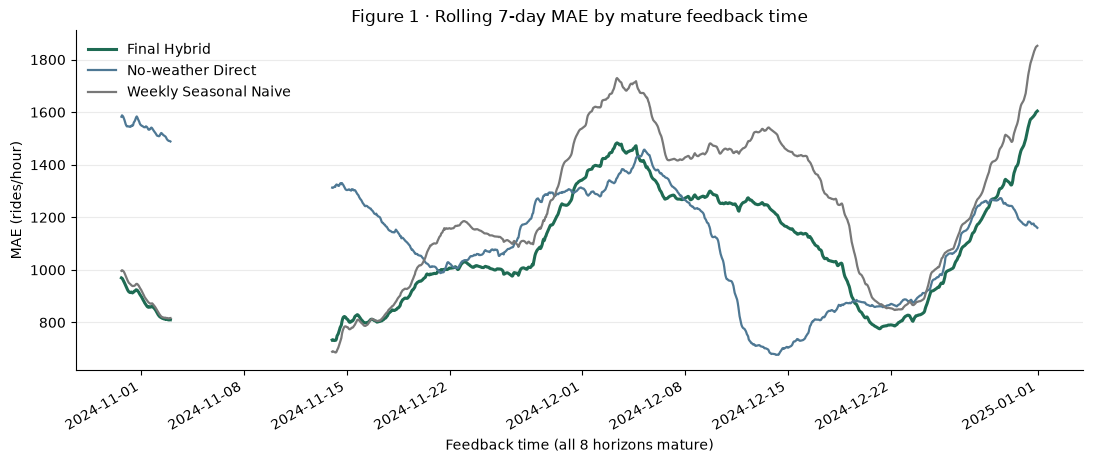

In [17]:
fig, ax = plt.subplots(figsize=(13, 5))
for strategy in STRATEGIES:
    ax.plot(rolling_mae.index, rolling_mae[strategy],
            label=strategy, color=palette[strategy],
            linewidth=2.2 if strategy == "Final Hybrid" else 1.6)
ax.set(title="Figure 1 · Rolling 7-day MAE by mature feedback time",
       xlabel="Feedback time (all 8 horizons mature)", ylabel="MAE (rides/hour)")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
fig.autofmt_xdate()
display(fig)
plt.close(fig)


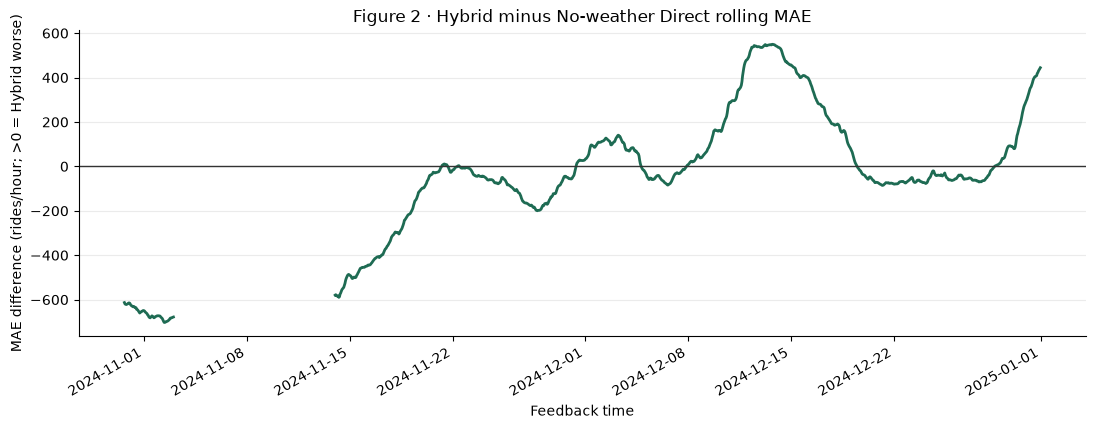

In [18]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(rolling_mae.index, rolling_mae["Hybrid minus No-weather Direct"],
        color=palette["Final Hybrid"], linewidth=2)
ax.axhline(0, color="#333333", linewidth=1)
ax.set(title="Figure 2 · Hybrid minus No-weather Direct rolling MAE",
       xlabel="Feedback time", ylabel="MAE difference (rides/hour; >0 = Hybrid worse)")
ax.grid(axis="y", alpha=0.25)
fig.autofmt_xdate()
display(fig)
plt.close(fig)


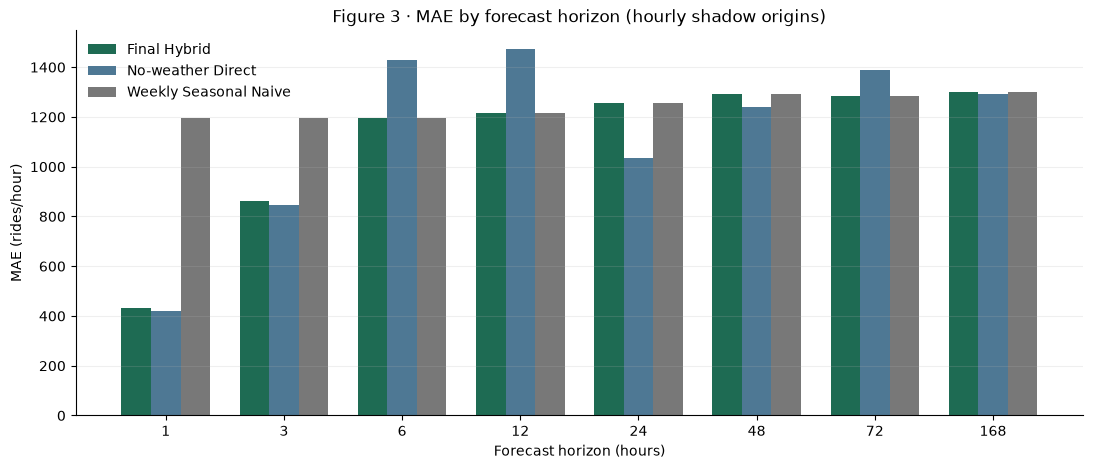

In [19]:
horizon_plot = horizon_metrics.pivot(
    index="Horizon", columns="Strategy", values="MAE"
)[list(STRATEGIES)]
x = np.arange(len(HORIZONS))
width = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
for offset, strategy in enumerate(STRATEGIES):
    ax.bar(x + (offset - 1) * width, horizon_plot[strategy], width,
           label=strategy, color=palette[strategy])
ax.set(title="Figure 3 · MAE by forecast horizon (hourly shadow origins)",
       xlabel="Forecast horizon (hours)", ylabel="MAE (rides/hour)",
       xticks=x, xticklabels=[str(h) for h in HORIZONS])
ax.set_ylim(bottom=0)
ax.grid(axis="y", alpha=0.2)
ax.legend(frameon=False)
display(fig)
plt.close(fig)


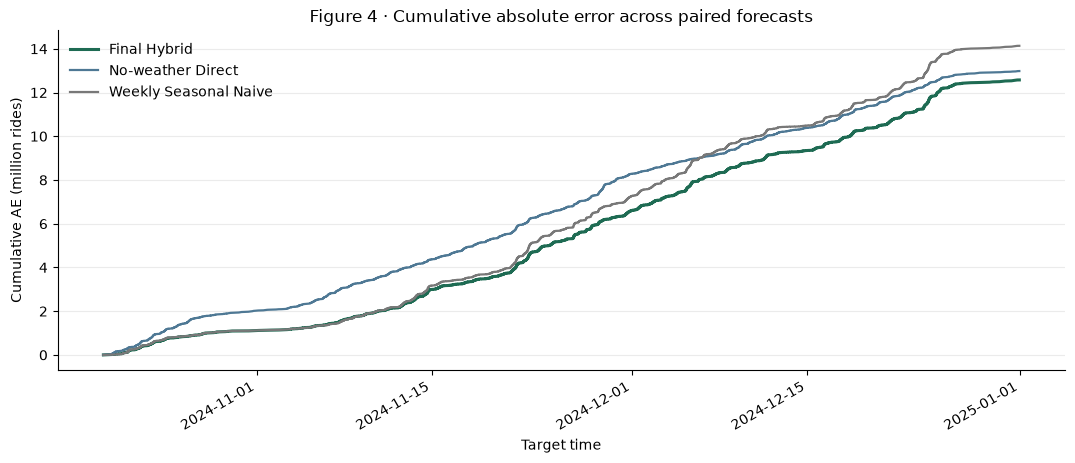

In [20]:
cumulative = prediction_log.sort_values(
    ["target_time", "origin_time", "horizon"], kind="stable"
).copy()
cumulative["cumulative_absolute_error"] = cumulative.groupby(
    "strategy", sort=False
)["absolute_error"].cumsum()
fig, ax = plt.subplots(figsize=(13, 5))
for strategy in STRATEGIES:
    series = cumulative.loc[cumulative["strategy"].eq(strategy)]
    ax.plot(series["target_time"], series["cumulative_absolute_error"] / 1_000_000,
            label=strategy, color=palette[strategy],
            linewidth=2.2 if strategy == "Final Hybrid" else 1.6)
ax.set(title="Figure 4 · Cumulative absolute error across paired forecasts",
       xlabel="Target time", ylabel="Cumulative AE (million rides)")
ax.grid(axis="y", alpha=0.25)
ax.legend(frameon=False)
fig.autofmt_xdate()
display(fig)
plt.close(fig)


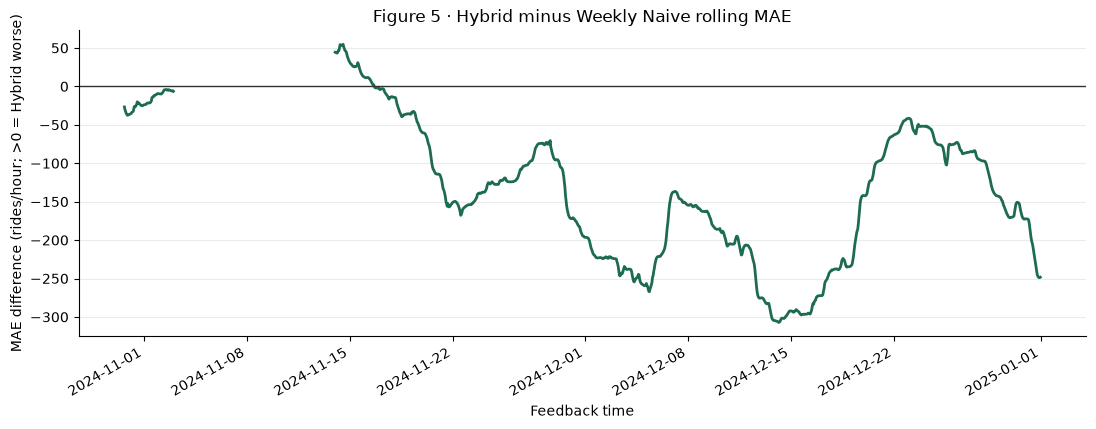

In [21]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(rolling_mae.index, rolling_mae["Hybrid minus Weekly Naive"],
        color=palette["Final Hybrid"], linewidth=2)
ax.axhline(0, color="#333333", linewidth=1)
ax.set(title="Figure 5 · Hybrid minus Weekly Naive rolling MAE",
       xlabel="Feedback time", ylabel="MAE difference (rides/hour; >0 = Hybrid worse)")
ax.grid(axis="y", alpha=0.25)
fig.autofmt_xdate()
display(fig)
plt.close(fig)


## Takeaways · A–D 与工程判断

**A. Hybrid 的优势是否仍存在？** 整体 MAE 比 No-weather Direct 低 3.13%，比 Weekly Naive 低 11.04%；但是 1h 与 3h 分别为 431.65 vs 419.03、862.43 vs 844.86，两个天气分支都没有胜过 No-weather Direct。6–168h 的 Hybrid 等于 Weekly（固定路由）；这六个 horizon 中，Weekly 仅在 6/12/72h 比 No-weather Direct 的 MAE 更低，不能说它全面主导长 horizon。

**B. 11 的 0.55% 是否稳定？** 原定四时刻子集精确复现 0.55%；小时级抽样得到 3.13%，但 12 月 Hybrid 比 No-weather Direct 差 27.17%。日末 rolling 窗口中 Hybrid 的胜率只有 62.3%，触发 3 段、12 天的研究 warning；最近成熟七日的 Hybrid MAE 1,604.29 vs No-weather 1,160.06。优势**不够稳定**，更不能把同一 2024 区间当独立未来盲测。

**C. Forecasted Weather 值得增加生产复杂度吗？** 当前证据不支持。1h/3h 天气分支在小时级回放均落后于 No-weather Direct。3h 差异还混有 Recursive 与 Direct 路线差别，不能单独归因降水；历史天气文件也不含真正预报发布时刻，观测发布延迟尚未验证。

**D. 工程建议。** 继续冻结 Hybrid 做研究型 shadow monitoring，不直接投入生产；需要低复杂度候选时优先 No-weather Direct。取得新的 2025 时间段和带发布时间的天气预报后再决定是否保留 Hybrid。不要依据这次 shadow 结果改路由或参数。

In [22]:
overall_lookup = overall_metrics.set_index("Strategy")
hybrid_mae = overall_lookup.loc["Final Hybrid", "MAE"]
no_weather_mae = overall_lookup.loc["No-weather Direct", "MAE"]
weekly_mae = overall_lookup.loc["Weekly Seasonal Naive", "MAE"]
nwd_improvement = 100 * (no_weather_mae - hybrid_mae) / no_weather_mae
weekly_improvement = 100 * (weekly_mae - hybrid_mae) / weekly_mae
early = grouped_tables["horizon"].loc[[1, 3]]
long = grouped_tables["horizon"].loc[[6, 12, 24, 48, 72, 168]]
long_weekly_wins = int((long["Weekly Seasonal Naive"] < long["No-weather Direct"]).sum())
print(f"A. 小时级历史 shadow：Hybrid MAE {hybrid_mae:.2f}；No-weather {no_weather_mae:.2f}；Weekly {weekly_mae:.2f}。")
print(f"   Hybrid 相对 No-weather 改善 {nwd_improvement:.2f}%，相对 Weekly 改善 {weekly_improvement:.2f}%。")
print("   1h/3h MAE：")
display(early[list(STRATEGIES)].round(2))
print(f"   6–168h 中 Weekly 比 No-weather Direct MAE 低的 horizon：{long_weekly_wins}/6；Hybrid 与 Weekly 在这些 horizon 完全相同。")
print(f"B. 原四时刻子集复现 11 的约 0.55% 优势；小时级扩展为 {nwd_improvement:.2f}%。")
print(f"   日末 rolling 胜率 vs No-weather {rolling_win_share_nwd:.1f}%；warning {warning_episodes} 段、{warning_days} 天。")
print("   这段已被研究过的 2024 时间不能独立证明未来优势稳定。")
print("C. 三策略对比不能把 3h 路线收益单独归因于预测降水；没有真实天气预报档案或发布延迟证据。")
if nwd_improvement <= 0 or warning_episodes > 0:
    recommendation = "维持研究型 shadow monitoring；如需低复杂度候选，优先 No-weather Direct。"
else:
    recommendation = "继续 shadow monitoring，等待全新时间段和真实 forecast issuance 数据，再决定是否保留 Hybrid。"
print("D. 工程建议：", recommendation)
print("锁定规则从未依据本 shadow 分数改变；以上判断不是生产上线许可。")


A. 小时级历史 shadow：Hybrid MAE 1104.69；No-weather 1140.38；Weekly 1241.80。
   Hybrid 相对 No-weather 改善 3.13%，相对 Weekly 改善 11.04%。
   1h/3h MAE：


strategy,Final Hybrid,No-weather Direct,Weekly Seasonal Naive
horizon,,,
1,431.65,419.03,1196.02
3,862.43,844.86,1194.97


   6–168h 中 Weekly 比 No-weather Direct MAE 低的 horizon：3/6；Hybrid 与 Weekly 在这些 horizon 完全相同。
B. 原四时刻子集复现 11 的约 0.55% 优势；小时级扩展为 3.13%。
   日末 rolling 胜率 vs No-weather 62.3%；warning 3 段、12 天。
   这段已被研究过的 2024 时间不能独立证明未来优势稳定。
C. 三策略对比不能把 3h 路线收益单独归因于预测降水；没有真实天气预报档案或发布延迟证据。
D. 工程建议： 维持研究型 shadow monitoring；如需低复杂度候选，优先 No-weather Direct。
锁定规则从未依据本 shadow 分数改变；以上判断不是生产上线许可。
